In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib # Import joblib here

# Load your dataset
df = pd.read_excel("prodCopy_CarHire.xlsx", sheet_name="Sheet1")

# Add binary cancellation label
df['Was_Cancelled'] = df['Cancellation_Status'].apply(lambda x: 1 if x == 1 else 0)

# Features to use
features = [
    'Price', 'Deposit_Amount', 'Net', 'Tax', 'Total',
    'Program', 'Locale', 'Currency_Code',
    'Booking_Type', 'Payment_Type'
]

# Drop rows with missing values
df = df[features + ['Was_Cancelled']].dropna()

# Encode categorical features
categorical_cols = ['Program', 'Locale', 'Currency_Code']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Prepare data
X = df[features]
y = df['Was_Cancelled']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importances)

# Save the trained model and label encoders
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

          Feature  Importance
0           Price    0.387481
4           Total    0.320239
2             Net    0.215838
7   Currency_Code    0.045568
3             Tax    0.030874
1  Deposit_Amount    0.000000
5         Program    0.000000
6          Locale    0.000000
8    Booking_Type    0.000000
9    Payment_Type    0.000000


['label_encoders.pkl']

<ipython-input-8-82c8d35eb2cd>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


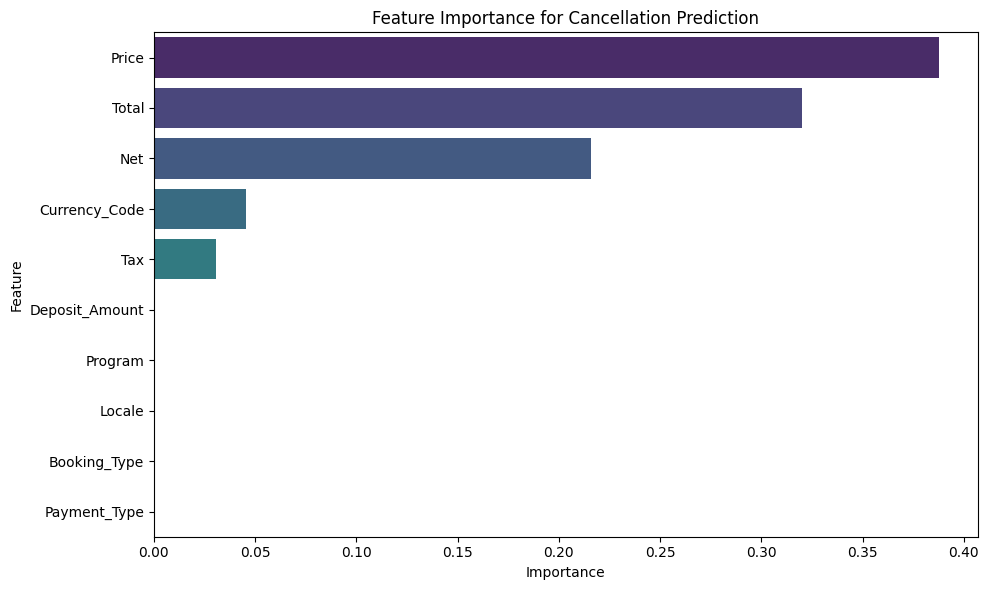

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming rf_model is your trained RandomForestClassifier and X is your feature DataFrame
# Changed 'clf' to 'rf_model' to match the variable name from the previous cell
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Cancellation Prediction')
plt.tight_layout()
plt.show()